In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('crime-housing-austin-2015.csv')
df.columns


Index(['Key', 'Council_District', 'Highest_Offense_Desc',
       'Highest_NIBRS_UCR_Offense_Description', 'Report_Date', 'Location',
       'Clearance_Status', 'Clearance_Date', 'District', 'Zip_Code_Crime',
       'Census_Tract', 'X_Coordinate', 'Y_Coordinate', 'Zip_Code_Housing',
       'Populationbelowpovertylevel', 'Medianhouseholdincome',
       'Non-WhiteNon-HispanicorLatino', 'HispanicorLatinoofanyrace',
       'Populationwithdisability', 'Unemployment',
       'Largehouseholds(5+members)',
       'Homesaffordabletopeopleearninglessthan$50000',
       'Rentalsaffordabletopeopleearninglessthan$25000',
       'Rent-restrictedunits', 'HousingChoiceVoucherholders', 'Medianrent',
       'Medianhomevalue', 'Percentageofrentalunitsinpoorcondition',
       'Percentchangeinnumberofhousingunits2000-2012',
       'Ownerunitsaffordabletoaverageretail/serviceworker',
       'Rentalunitsaffordabletoaverageretail/serviceworker',
       'Rentalunitsaffordabletoaverageartist',
       'Ownerunits

--- Clearance Rate Statistics (Across Crime Types) ---
Average Clearance Rate: 29.16%
Standard Deviation:     27.67%



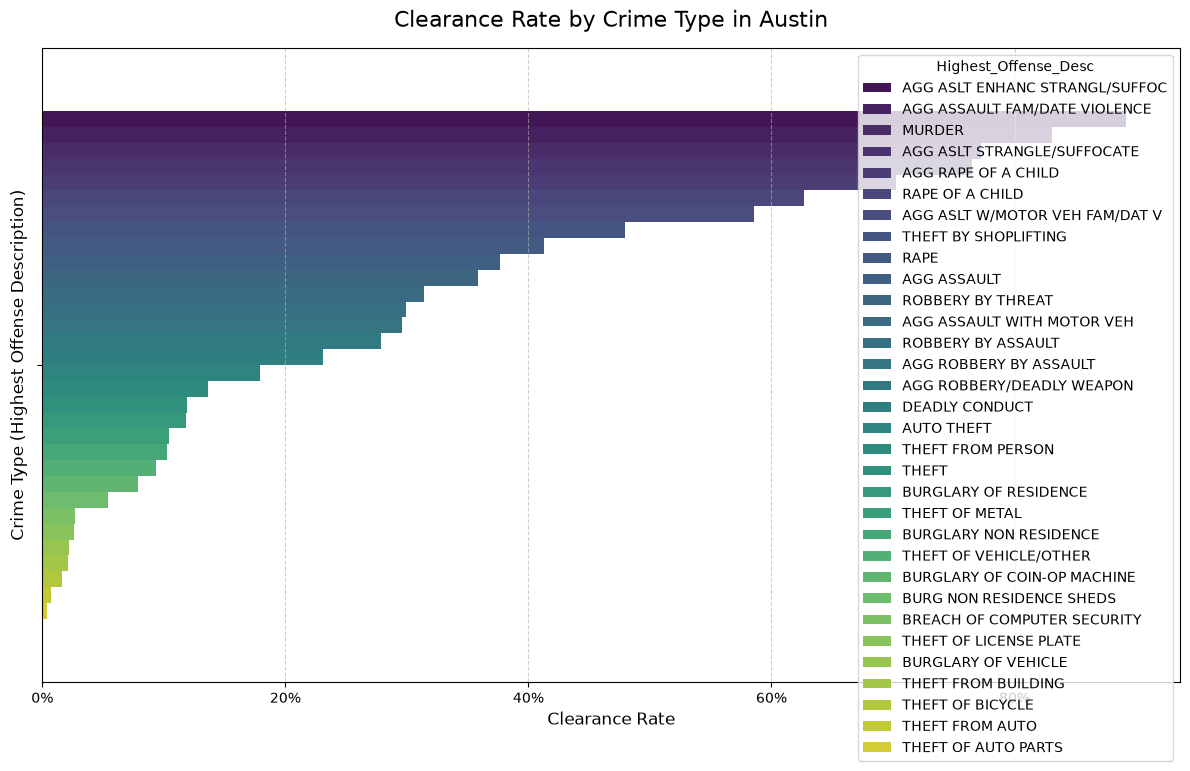

In [10]:
# 1. Create a binary 'Cleared' flag
# Assuming 'C' (Cleared by Arrest) and 'O' (Cleared by Exception) mean the case is cleared
df['Is_Cleared'] = df['Clearance_Status'].isin(['C', 'O']).astype(int)

# 2. Calculate Clearance Rate by Crime Type
# Get the mean (which translates to the clearance rate) and the total count of cases
clearance_rates = df.groupby('Highest_Offense_Desc')['Is_Cleared'].agg(['mean', 'count']).reset_index()
clearance_rates.rename(columns={'mean': 'Clearance_Rate', 'count': 'Total_Cases'}, inplace=True)

# Filter out extremely rare crimes (e.g., fewer than 20 cases) to prevent skewed 0% or 100% outliers, 
# then sort for visualization
top_crimes = clearance_rates[clearance_rates['Total_Cases'] > 20].sort_values(by='Clearance_Rate', ascending=False)

# 3. Calculate Averages and Standard Deviations (across the different crime types)
avg_clearance = top_crimes['Clearance_Rate'].mean()
std_clearance = top_crimes['Clearance_Rate'].std()

print("--- Clearance Rate Statistics (Across Crime Types) ---")
print(f"Average Clearance Rate: {avg_clearance*100:.2f}%")
print(f"Standard Deviation:     {std_clearance*100:.2f}%\n")

# 4. Create the Bar Chart
plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_crimes, 
    x='Clearance_Rate', 
    hue='Highest_Offense_Desc',
    palette='viridis'
)

# Formatting the plot
plt.title('Clearance Rate by Crime Type in Austin', fontsize=16, pad=15)
plt.xlabel('Clearance Rate', fontsize=12)
plt.ylabel('Crime Type (Highest Offense Description)', fontsize=12)

# Format x-axis as percentages
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

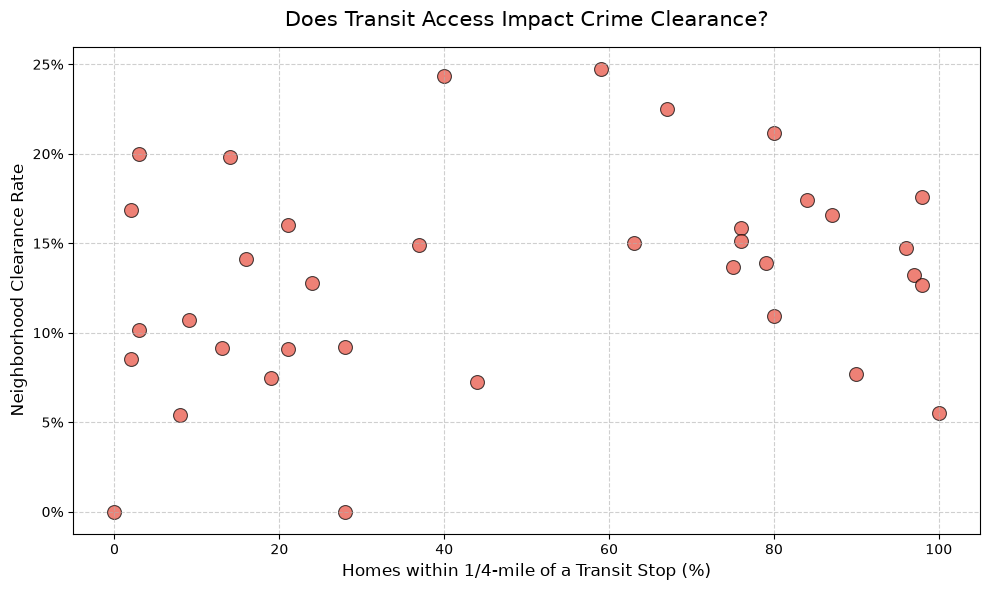

In [12]:
# 1. Ensure the binary 'Is_Cleared' flag exists
if 'Is_Cleared' not in df.columns:
    df['Is_Cleared'] = df['Clearance_Status'].isin(['C', 'O']).astype(int)

# 2. Ensure Transit Accessibility is cleaned and numeric
df['Transit_Access'] = df['Percentageofhomeswithin1/4-mioftransitstop'].astype(str).replace(r'[%]', '', regex=True)
df['Transit_Access'] = pd.to_numeric(df['Transit_Access'], errors='coerce')

# 3. Group by Zip Code to create neighborhood-level statistics
# (Removing the minimum crime filter so every neighborhood dot is placed)
neighborhood_stats = df.groupby('Zip_Code_Crime').agg(
    Clearance_Rate=('Is_Cleared', 'mean'),
    Transit_Access=('Transit_Access', 'mean')
).reset_index().dropna(subset=['Transit_Access', 'Clearance_Rate'])

# 4. Create the Scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=neighborhood_stats, 
    x='Transit_Access', 
    y='Clearance_Rate',
    s=100,           # Uniform dot size for all points
    alpha=0.7,
    color='#e74c3c',
    edgecolor='black'
)

# Formatting the plot
plt.title('Does Transit Access Impact Crime Clearance?', fontsize=15, pad=15)
plt.xlabel('Homes within 1/4-mile of a Transit Stop (%)', fontsize=12)
plt.ylabel('Neighborhood Clearance Rate', fontsize=12)

# Format y-axis as percentages
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

In [ ]:
# Split data into High Transit (above 50% access) and Low Transit (below 50% access)
high_transit = neighborhood_stats[neighborhood_stats['Transit_Access'] >= 50]['Clearance_Rate']
low_transit = neighborhood_stats[neighborhood_stats['Transit_Access'] < 50]['Clearance_Rate']

# Run an independent T-test
t_stat, p_val = stats.ttest_ind(high_transit, low_transit, nan_policy='omit')

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value:     {p_val:.4f}")
if p_val < 0.05:
    print("Conclusion: There IS a significant difference in clearance rates based on transit access.")
else:
    print("Conclusion: There is NO significant difference in clearance rates based on transit access.")